In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Two-Cell Relaxation Analytical Reference

This notebook computes analytical reference values for a two-cell relaxation benchmark using the extended Hertz contact model. It is intended for validating a numerical implementation of the extended Hertz force law before comparing full simulation trajectories.

The setup is:
- Two spherical cells
- Equal radii $R_i = R_j = 5\,\mu\mathrm{m}$
- Initial center-to-center distance $d_0 = 9\,\mu\mathrm{m}$
- Initial overlap $\delta_0 = R_i + R_j - d_0 = 1\,\mu\mathrm{m}$

All calculations are performed internally in SI units: meters, Newtons, Pascals, and $\mathrm{J}/\mathrm{m}^2$.

## Model and Definitions



The scalar extended Hertz force is



$$

F_{\mathrm{eHertz}}(\delta) = \frac{4 \tilde{E}}{3} \sqrt{\tilde{R}} \, \delta^{3/2} - \pi \gamma \tilde{R},

$$



where:

- $\tilde{E}$ is the composite Young modulus

- $\gamma$ is the adhesion energy density

- $\delta$ is the overlap

- $\tilde{R}$ is the effective radius

with units : 

- $F_{ij}^{eHertz}$ : force $(\mathrm{N})$

- $\tilde E_{ij}$ : composite Young modulus $(\mathrm{Pa} = \mathrm{N}/\mathrm{m}^2)$

- $\tilde R$ : effective radius $(\mathrm{m})$

- $\delta$ : overlap deformation $(\mathrm{m})$

- $\gamma$ : adhesion energy density $(\mathrm{J}/\mathrm{m}^2 = \mathrm{N}/\mathrm{m})$

- $R_i, R_j$ : cell radii $(\mathrm{m})$

- $d_{ij}$ : center-to-center distance between cells $(\mathrm{m})$

- $\nu_i, \nu_j$ : Poisson ratios (dimensionless)

- $E_i, E_j$ : Young modulus of each cell $(\mathrm{Pa})$



simplified :



$$

F_{ij}^{eHertz}

=

\frac{4}{3}

\underbrace{\tilde E_{ij}}_{\mathrm{Pa}}

\underbrace{\sqrt{\tilde R}}_{\mathrm{m}^{1/2}}

\underbrace{\delta^{3/2}}_{\mathrm{m}^{3/2}}

-

\pi

\underbrace{\gamma}_{\mathrm{\frac{N}{m}}}

\underbrace{\tilde {R}}_{\mathrm{m}}

\\

$$

$$

F_{ij}^{eHertz} \in \mathrm{N}



$$

For two spheres, the effective radius is



$$

\tilde{R} = \left(\frac{1}{R_i} + \frac{1}{R_j}\right)^{-1}.

$$



The equilibrium overlap follows from $F_{\mathrm{eHertz}}(\delta_{eq}) = 0$:



$$

\delta_{eq} = \left(\frac{3 \pi \gamma \sqrt{\tilde{R}}}{4 \tilde{E}}\right)^{2/3}.

$$



The corresponding equilibrium center distance is



$$

d_{eq} = R_i + R_j - \delta_{eq}.

$$

## Adhesion parameter



The adhesion parameter is defined from the adhesion molecule surface density $\sigma_m$ and the single-bond work $W_s$ as



$$

\gamma = \varsigma_s W_s,

$$



with



$$

W_s = 20 \, k_B T

$$

. Then

- Adhesion density $\varsigma_m = 10^{15}\,\mathrm{m}^{-2}$.

- Single-bond work $W_s = 20 k_B T$ at $T = 310\,\mathrm{K}$ and $k_b = 1.38\cdot10^{-23}$.



$$



\gamma = 10^{15}\,\mathrm{m}^{-2} \cdot 20 \cdot 310K \cdot 1.38\cdot 10^{-23} \frac{J}{K}.

\\

\gamma = 8.56\cdot 10^{-5} \frac{J}{\mathrm{m}^{2}}

$$



## Composite Modulus

Assuming that the variable provided in the table as Young’s Modulus and with value 450Pa is each cells young modulus $\tilde{E}_{i}$

then we calculate the composite youngs modulus with



$\tilde{E}_{i} = \tilde{E}_{j} = 450 Pa$



and Poisson ratio 



 $v_i=v_j=0.4 $

The composite Young modulus used in the extended Hertz model is then computed as:



$\tilde{E}^{-1}_{ij} = (1 - v^{2}_{i}) E^{ -1 }_{i} + (1 - v^{2}_{j}) E^{ -1 }_{j}.$



Since both cells are assumed to have identical mechanical properties, the expression simplifies to:



$\tilde{E}_{ij} =  \frac{E}{2 \cdot( 1 - v^{2})}$



then



$\tilde{E}_{ij} = \frac{450}{2 \cdot (1 - 0.4^{2})} $



$\tilde{E}_{ij} \approx 268 Pa$





## TAKE CARE AND IF YOUR MODEL IS USING UM TO CONVERT THE UM TO M

In [2]:
# Unit conversion factors

MICROMETER_TO_METER = 1e-6

NEWTON_TO_NANONEWTON = 1e9

NEWTON_TO_PICONEWTON = 1e12



# Problem parameters in readable units

R_i_um = 5.0

R_j_um = 5.0

d_0_um = 9.0

# E_tilde_pa = 450.0

E_tilde_pa = 268.0

gamma_j_per_m2 = 8.56e-05



# Convert all geometric quantities to SI units

R_i = R_i_um * MICROMETER_TO_METER

R_j = R_j_um * MICROMETER_TO_METER

d_0 = d_0_um * MICROMETER_TO_METER

E_tilde = E_tilde_pa

gamma = gamma_j_per_m2



# Derived quantities in SI units

delta_0 = R_i + R_j - d_0

R_tilde = 1.0 / (1.0 / R_i + 1.0 / R_j)



def extended_hertz_force(delta: np.ndarray | float) -> np.ndarray | float:

    delta_array = np.asarray(delta, dtype=float)

    force = (4.0 * E_tilde / 3.0) * np.sqrt(R_tilde) * np.power(delta_array, 1.5) - np.pi * gamma * R_tilde

    if np.isscalar(delta):

        return float(force)

    return force



F_delta_0 = extended_hertz_force(delta_0)

delta_eq = ((3.0 * np.pi * gamma * np.sqrt(R_tilde)) / (4.0 * E_tilde)) ** (2.0 / 3.0)

d_eq = R_i + R_j - delta_eq



print(f'Initial overlap delta_0 = {delta_0 / MICROMETER_TO_METER:.6f} um')

print(f'Effective radius R_tilde = {R_tilde / MICROMETER_TO_METER:.6f} um')

print(f'Initial force F(delta_0) = {F_delta_0 * NEWTON_TO_NANONEWTON:.6f} nN')

print(f'Equilibrium overlap delta_eq = {delta_eq / MICROMETER_TO_METER:.6f} um')

print(f'Equilibrium distance d_eq = {d_eq / MICROMETER_TO_METER:.6f} um')

Initial overlap delta_0 = 1.000000 um
Effective radius R_tilde = 2.500000 um
Initial force F(delta_0) = -0.107307 nN
Equilibrium overlap delta_eq = 1.122915 um
Equilibrium distance d_eq = 8.877085 um


## Summary Table

The table below reports each quantity in SI units and in a more readable scale for inspection and benchmark documentation.

In [3]:
summary = pd.DataFrame(
    [
        {'quantity': 'R_i', 'value_SI': R_i, 'SI_unit': 'm', 'readable_value': R_i_um, 'readable_unit': 'um'},
        {'quantity': 'R_j', 'value_SI': R_j, 'SI_unit': 'm', 'readable_value': R_j_um, 'readable_unit': 'um'},
        {'quantity': 'd_0', 'value_SI': d_0, 'SI_unit': 'm', 'readable_value': d_0_um, 'readable_unit': 'um'},
        {'quantity': 'delta_0', 'value_SI': delta_0, 'SI_unit': 'm', 'readable_value': delta_0 / MICROMETER_TO_METER, 'readable_unit': 'um'},
        {'quantity': 'R_tilde', 'value_SI': R_tilde, 'SI_unit': 'm', 'readable_value': R_tilde / MICROMETER_TO_METER, 'readable_unit': 'um'},
        {'quantity': 'E_tilde', 'value_SI': E_tilde, 'SI_unit': 'Pa', 'readable_value': E_tilde, 'readable_unit': 'Pa'},
        {'quantity': 'gamma', 'value_SI': gamma, 'SI_unit': 'J/m^2', 'readable_value': gamma, 'readable_unit': 'J/m^2'},
        {'quantity': 'F(delta_0)', 'value_SI': F_delta_0, 'SI_unit': 'N', 'readable_value': F_delta_0 * NEWTON_TO_NANONEWTON, 'readable_unit': 'nN'},
        {'quantity': 'delta_eq', 'value_SI': delta_eq, 'SI_unit': 'm', 'readable_value': delta_eq / MICROMETER_TO_METER, 'readable_unit': 'um'},
        {'quantity': 'd_eq', 'value_SI': d_eq, 'SI_unit': 'm', 'readable_value': d_eq / MICROMETER_TO_METER, 'readable_unit': 'um'},
    ]
)

display(
    summary.style.format({
        'value_SI': '{:.6e}',
        'readable_value': '{:.6f}',
    })
)

,quantity,value_SI,SI_unit,readable_value,readable_unit
0,R_i,5.000000e-06,m,5.000000,um
1,R_j,5.000000e-06,m,5.000000,um
2,d_0,9.000000e-06,m,9.000000,um
3,delta_0,1.000000e-06,m,1.000000,um
4,R_tilde,2.500000e-06,m,2.500000,um
5,E_tilde,2.680000e+02,Pa,268.000000,Pa
6,gamma,8.560000e-05,J/m^2,0.000086,J/m^2
7,F(delta_0),-1.073072e-10,N,-0.107307,nN
8,delta_eq,1.122915e-06,m,1.122915,um
9,d_eq,8.877085e-06,m,8.877085,um


## Force-Overlap Curve

This plot shows the analytical extended Hertz force as a function of overlap. The markers identify the initial overlap $\delta_0$ and the equilibrium overlap $\delta_{eq}$.

A positive force corresponds to net repulsion from elastic deformation. A negative value corresponds to a net attractive contribution from adhesion dominating the elastic term at small overlap.

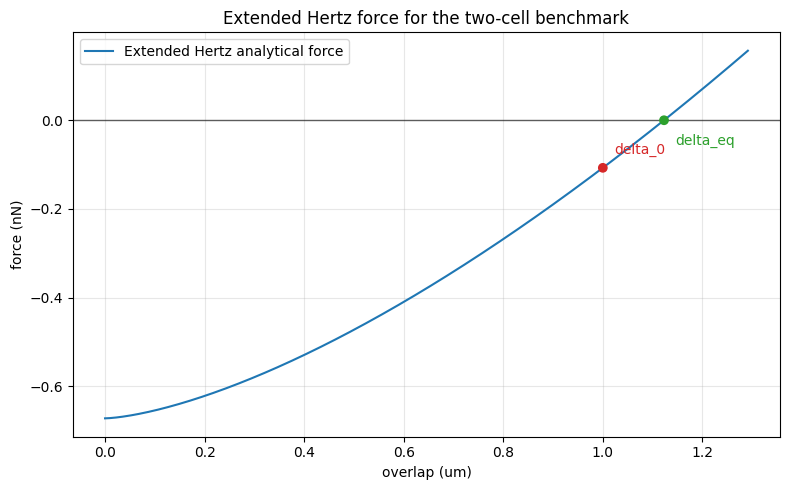

In [4]:
delta_max = max(1.15 * delta_0, 1.15 * delta_eq)
delta_values = np.linspace(0.0, delta_max, 400)
force_values = extended_hertz_force(delta_values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(delta_values / MICROMETER_TO_METER, force_values * NEWTON_TO_NANONEWTON, label='Extended Hertz analytical force', color='tab:blue')
ax.axhline(0.0, color='black', linewidth=1.0, alpha=0.6)
ax.scatter(
    [delta_0 / MICROMETER_TO_METER, delta_eq / MICROMETER_TO_METER],
    [F_delta_0 * NEWTON_TO_NANONEWTON, extended_hertz_force(delta_eq) * NEWTON_TO_NANONEWTON],
    color=['tab:red', 'tab:green'],
    zorder=3,
)
ax.annotate(
    'delta_0',
    xy=(delta_0 / MICROMETER_TO_METER, F_delta_0 * NEWTON_TO_NANONEWTON),
    xytext=(8, 10),
    textcoords='offset points',
    color='tab:red',
)
ax.annotate(
    'delta_eq',
    xy=(delta_eq / MICROMETER_TO_METER, extended_hertz_force(delta_eq) * NEWTON_TO_NANONEWTON),
    xytext=(8, -18),
    textcoords='offset points',
    color='tab:green',
)
ax.set_xlabel('overlap (um)')
ax.set_ylabel('force (nN)')
ax.set_title('Extended Hertz force for the two-cell benchmark')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Force-Overlap Curve for Different Adhesion Values



This section plots the same analytical force-overlap curve for several values of the adhesion parameter $\gamma$. It is useful for seeing how stronger or weaker adhesion shifts the force curve and changes the equilibrium overlap.

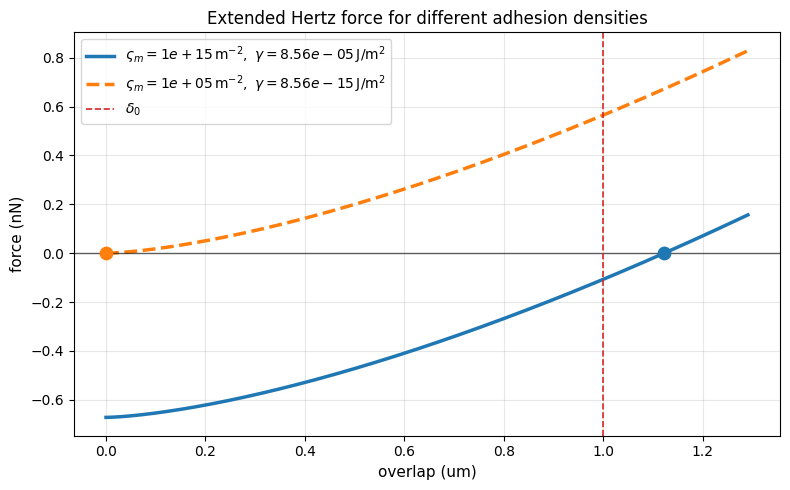

,adhesion_density_m^-2,gamma_J_per_m^2,delta_eq_um,d_eq_um
0,1e+15,8.556000e-05,1.122565,8.877435
1,1e+05,8.556000e-15,0.000000,10.000000


In [3]:
adhesion_density_values = [1e15, 1e5]



boltzmann_constant = 1.38e-23

temperature_k = 310.0

single_bond_work = 20.0 * boltzmann_constant * temperature_k

gamma_values = [adhesion_density * single_bond_work for adhesion_density in adhesion_density_values]



def extended_hertz_force_with_gamma(delta: np.ndarray | float, gamma_value: float) -> np.ndarray | float:

    delta_array = np.asarray(delta, dtype=float)

    force = (4.0 * E_tilde / 3.0) * np.sqrt(R_tilde) * np.power(delta_array, 1.5) - np.pi * gamma_value * R_tilde

    if np.isscalar(delta):

        return float(force)

    return force



delta_eq_values = [((3.0 * np.pi * gamma_value * np.sqrt(R_tilde)) / (4.0 * E_tilde)) ** (2.0 / 3.0) for gamma_value in gamma_values]

d_eq_values = [R_i + R_j - delta_eq_value for delta_eq_value in delta_eq_values]

delta_gamma_max = max([delta_0, *delta_eq_values]) * 1.15

delta_gamma_values = np.linspace(0.0, delta_gamma_max, 400)



fig, ax = plt.subplots(figsize=(8, 5))



for adhesion_density, gamma_value, gamma_delta_eq in zip(adhesion_density_values, gamma_values, delta_eq_values):

    gamma_force_values = extended_hertz_force_with_gamma(delta_gamma_values, gamma_value)

    ax.plot(

        delta_gamma_values / MICROMETER_TO_METER,

        gamma_force_values * NEWTON_TO_NANONEWTON,

        label=(

            fr'$\varsigma_m={adhesion_density:.0e}\,\mathrm{{m^{{-2}}}},\ '

            fr'\gamma={gamma_value:.2e}\,\mathrm{{J/m^2}}$'

        ),

    )

    ax.scatter(

        [gamma_delta_eq / MICROMETER_TO_METER],

        [extended_hertz_force_with_gamma(gamma_delta_eq, gamma_value) * NEWTON_TO_NANONEWTON],

        s=25,

        zorder=3,

    )



ax.axhline(0.0, color='black', linewidth=1.0, alpha=0.6)

ax.axvline(delta_0 / MICROMETER_TO_METER, color='tab:red', linestyle='--', linewidth=1.2, label=r'$\delta_0$')

ax.set_xlabel('overlap (um)')

ax.set_ylabel('force (nN)')

ax.set_title('Extended Hertz force for different adhesion densities')

ax.grid(True, alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()



equilibrium_summary = pd.DataFrame(

    {

        'adhesion_density_m^-2': adhesion_density_values,

        'gamma_J_per_m^2': gamma_values,

        'delta_eq_um': [delta_eq_value / MICROMETER_TO_METER for delta_eq_value in delta_eq_values],

        'd_eq_um': [d_eq_value / MICROMETER_TO_METER for d_eq_value in d_eq_values],

    }

)



display(

    equilibrium_summary.style.format(

        {

            'adhesion_density_m^-2': '{:.0e}',

            'gamma_J_per_m^2': '{:.6e}',

            'delta_eq_um': '{:.6f}',

            'd_eq_um': '{:.6f}',

        }

    )

)